<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Preparación de los Datos:
</h1>

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

import tensorflow as tf
# Esto silencia los logs internos de Python de TF también
import logging
tf.get_logger().setLevel('ERROR')

#Con este codigo desactivamos los warnings y así no tenemos tanta basura en los logs
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [12]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

import tensorflow as tf
# Esto silencia los logs internos de Python de TF también
import logging
tf.get_logger().setLevel('ERROR')

#Con este codigo desactivamos los warnings y así no tenemos tanta basura en los logs
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [2]:
import pandas as pd #1.3.5
import numpy as np
import sklearn.preprocessing as skpr
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt 
import time
import keras_hub

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import metrics
from keras.callbacks import EarlyStopping
from keras.models import Model
from keras.layers import LSTM, GRU, Activation, Dense, Dropout, Input, Embedding, SimpleRNN
from tensorflow.keras.optimizers import RMSprop
from sklearn.preprocessing import MaxAbsScaler
from tensorflow.keras import layers, regularizers

df = pd.read_csv('./DF4/df4.csv', sep=';') #El csv está separado por ';' en vez de por ',' como es por defecto.

print(df)

/mnt/data/Venvs/venv2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


            Type Cate_1 Cate_2 Cate_3  \
0       Paciente    TEA    NaN    NaN   
1       Paciente    TEA    NaN    NaN   
2       Paciente    TEA    NaN    NaN   
3       Paciente    TEA    NaN    NaN   
4       Paciente    TEA    NaN    NaN   
...          ...    ...    ...    ...   
404622     Madre    TEA    NaN    NaN   
404623     Madre    TEA    NaN    NaN   
404624     Madre    TEA    NaN    NaN   
404625     Madre    TEA    NaN    NaN   
404626     Madre    TEA    NaN    NaN   

                                                    tweet  
0       Hey guys please if you can help my friend Lars...  
1       I also had some DM requests that vanished inst...  
2       Anyway I’m gonna keep an eye on this account a...  
3       Art stopped being fun for me for a while becau...  
4       I’ve also been staying away from this account ...  
...                                                   ...  
404622  Never again can @carlalockhart claim to be ‘Pr...  
404623                    A

/tmp/ipykernel_11332/238368153.py:21: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./DF4/df4.csv', sep=';') #El csv está separado por ';' en vez de por ',' como es por defecto.


In [3]:
#1 - 45K tweet with TEA/ASP patients and 45K tweets padre/madre/familia
t_pacientes= df.loc[(df["Type"]=="Paciente")]
t_familia= df.loc[(df["Type"]!="Paciente")]

data1_paciente = t_pacientes.sample(n=45000)
data1_familia = t_familia.sample(n=45000)


""" #TEA /// ASP
temp_TEA=t_pacientes.loc[(t_pacientes["Cate_1"] == "TEA") & (t_pacientes["Cate_2"] != "ASP")] 
temp_ASP=t_pacientes.loc[(t_pacientes["Cate_1"] == "ASP") & (t_pacientes["Cate_2"] != "TEA")]

print(len(temp_ASP))

data2_paciente_TEA = temp_TEA.sample(n=87000)
temp_n = len(temp_ASP)
data2_paciente_ASP = temp_ASP.sample(n=temp_n)

#TA /// TDAH
temp_TA=t_pacientes.loc[(t_pacientes["Cate_2"].isnull())] 
temp_TDAH=t_pacientes.loc[(t_pacientes["Cate_2"] == "TDAH") | (t_pacientes["Cate_3"] == "TDAH")]

data3_paciente_TA = temp_TA.sample(n=70000)
temp_n = len(temp_TDAH)
data3_paciente_TDAH = temp_TDAH.sample(n=temp_n) """



features = pd.concat([data1_paciente, data1_familia], ignore_index=True)
labels_aux = np.array(features['Type'])
labels = [1 if x == 'Paciente' else 0 for x in labels_aux]

print(features.head(5))
print("--------------------------")

features = features.drop('Type', axis = 1)
features = features.drop('Cate_1', axis = 1)
features = features.drop('Cate_2', axis = 1)
features = features.drop('Cate_3', axis = 1)
print(features.head(5))

       Type Cate_1 Cate_2 Cate_3  \
0  Paciente    ASP    NaN    NaN   
1  Paciente    TEA    NaN    NaN   
2  Paciente    ASP   TEPT    NaN   
3  Paciente    TEA    NaN    NaN   
4  Paciente    TEA    NaN    NaN   

                                               tweet  
0  I thought it was a joke, but it actually exist...  
1  Probably had a few too many beers for Christma...  
2  Joanne Shenandoah – Living Symbol Of Positive ...  
3  can we all appreciate my moms outfit for her h...  
4  Dump him, preferably in the middle of the ocea...  
--------------------------
                                               tweet
0  I thought it was a joke, but it actually exist...
1  Probably had a few too many beers for Christma...
2  Joanne Shenandoah – Living Symbol Of Positive ...
3  can we all appreciate my moms outfit for her h...
4  Dump him, preferably in the middle of the ocea...


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer as tf_idf
from sklearn.feature_extraction.text import CountVectorizer

label_encoder = skpr.LabelEncoder()
cv = CountVectorizer(max_features=2500)
tfidf = tf_idf(norm=None, max_features=2500) #max_features=2500 para que quepa en memoria

save_features = features
X_train, X_test, Y_train, Y_test=train_test_split(save_features['tweet'], labels, test_size= 0.25, random_state = 42)

Y_train_ = label_encoder.fit_transform(Y_train)
Y_test_ = label_encoder.transform(Y_test)

# Convertimos a lista de Python y luego a tensor de strings de TF
# Esto evita el error del dtype str10816
X_train_final = tf.constant(np.array(X_train, dtype=object))
X_test_final = tf.constant(np.array(X_test, dtype=object))

Y_train_fixed = Y_train_.reshape(-1, 1)
Y_test_fixed = Y_test_.reshape(-1, 1)

I0000 00:00:1778492606.429890   11332 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4280 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
X_train_scaled = cv.fit_transform(X_train)
X_test_scaled  = cv.transform(X_test)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test) #Solo usaré estos para MLP

scaler = MaxAbsScaler()
X_train_tfidf = scaler.fit_transform(X_train_tfidf)
X_test_tfidf = scaler.transform(X_test_tfidf)

scaler = MaxAbsScaler()
X_train_cv = scaler.fit_transform(X_train_scaled)
X_test_cv = scaler.transform(X_test_scaled)

X_train_cv = X_train_cv.toarray().reshape(X_train_cv.shape[0], 1, X_train_cv.shape[1])
X_test_cv = X_test_cv.toarray().reshape(X_test_cv.shape[0], 1, X_test_cv.shape[1])

X_train_tfidf = X_train_tfidf.toarray().reshape(X_train_tfidf.shape[0], 1, X_train_tfidf.shape[1])
X_test_tfidf = X_test_tfidf.toarray().reshape(X_test_tfidf.shape[0], 1, X_test_tfidf.shape[1])

input_dim = X_train_scaled.shape[1]
print(f"Tras aplicar Count Vectorizer la dimensión de entrada es: {input_dim}")

Tras aplicar Count Vectorizer la dimensión de entrada es: 2500


In [6]:
import numpy as np
from gensim.models import Word2Vec
import nltk

# Aseguramos la descarga del tokenizador
nltk.download('punkt')

# 1. Tokenizar los textos
train_tokens = [nltk.word_tokenize(text.lower()) for text in X_train]
test_tokens = [nltk.word_tokenize(text.lower()) for text in X_test]

# 2. Entrenar el modelo Word2Vec con parámetros por defecto
# Solo especificamos workers=4 según tu requerimiento.
# Por defecto: vector_size=100, window=5, min_count=5.
w2v_model = Word2Vec(sentences=train_tokens, workers=8)

# 3. Función para promediar vectores (usando el tamaño por defecto: 100)
def get_average_vector(tokens, model, size=100):
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(size)
    return np.mean(vectors, axis=0)

# 4. Transformar los datos a embeddings promediados
X_train_emb = np.array([get_average_vector(t, w2v_model) for t in train_tokens])
X_test_emb = np.array([get_average_vector(t, w2v_model) for t in test_tokens])

[nltk_data] Downloading package punkt to /home/xeihtt/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Longitud media: 21.989955555555557
Longitud máxima: 66


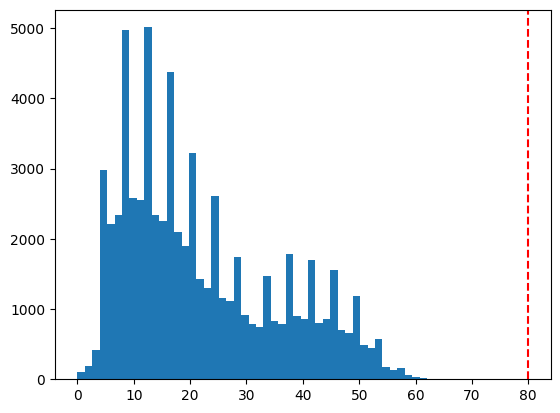

In [82]:
max_words=25000
tok = Tokenizer(num_words=max_words)
tok.fit_on_texts(X_train)
sequences = tok.texts_to_sequences(X_train)

import matplotlib.pyplot as plt

# Contar palabras por tweet
lengths = [len(s) for s in sequences]

print(f"Longitud media: {np.mean(lengths)}")
print(f"Longitud máxima: {np.max(lengths)}")

# Visualizar para ver si 80 cubre el 99% de los casos
plt.hist(lengths, bins=50)
plt.axvline(x=80, color='r', linestyle='--')
plt.show()

max_len_ = 55
train_sequences_matrix = pad_sequences(sequences,maxlen=max_len_)

test_sequences = tok.texts_to_sequences(X_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len_) #Usaré esto para el resto de modelos

In [58]:
max_words=1000  #Anotacion: Esta forma de inicializar las secuencias son las que se han usado para los modelos RNN, LSTM y Bi-LSTM, es la misma forma que usaban los competidores
# ya que esos son sus modelos.
tok = Tokenizer(num_words=max_words)
tok.fit_on_texts(X_train)
sequences = tok.texts_to_sequences(X_train)
max_len_ = 200
train_sequences_matrix = pad_sequences(sequences,maxlen=max_len_) #Estándar

test_sequences = tok.texts_to_sequences(X_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len_)

In [87]:
def plot_training_history(history):
    """
    Grafica la evolución de la pérdida y la precisión durante el entrenamiento.

    Args:
        history (dict): Diccionario que contiene las métricas de entrenamiento. 
                          Debe contener las claves "train_loss", "val_loss", "train_acc" y "val_acc".
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Loss
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history["train_acc"], label="Train Accuracy")
    axes[1].plot(history["val_acc"], label="Validation Accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training and Validation Accuracy")
    axes[1].legend()

    plt.show()

def create_embedding_matrix(tokenizer, max_words, embedding_dim=200): #TODO: Cambiar la dimension a 100 cuando cambie de embedding
    embeddings_index = {}
    
    # Abrimos el archivo con 'utf8' para evitar errores de caracteres
    with open('./glove.embeddings/glove.twitter.27B.200d.txt', encoding='utf8') as f:
        for line in f:
            values = line.split()
            # Una línea válida debe tener la palabra + las dimensiones (1 + 100 = 101)
            if len(values) != embedding_dim + 1:
                continue 
                
            word = values[0]
            try:
                coefs = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = coefs
            except ValueError:
                # Si alguna palabra tiene un formato de número raro, la saltamos
                continue

    # Crear la matriz final
    embedding_matrix = np.zeros((max_words, embedding_dim))
    misses=0
    for word, i in tokenizer.word_index.items():
        if i < max_words:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
            else:
                misses +=1
    
    print(f"En total, quedan: {misses} palabras fuera de GloVe")
    return embedding_matrix

# Generamos la matriz usando tu Tokenizer
embedding_matrix = create_embedding_matrix(tok, max_words=25000)

En total, quedan: 5435 palabras fuera de GloVe


<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Pruebas del modelo: RNN
</h1>

In [57]:
%matplotlib inline

def RNN():
    inputs = Input(name='inputs',shape=[max_len_])
    #layer = Embedding(max_words,50,input_length=max_len_)(inputs)
    layer = Embedding(max_words,50,)(inputs)
    #layer = LSTM(100)(layer)
    layer = SimpleRNN(100)(layer)
    layer = Dense(256,name='FC1')(layer)
    layer = Activation('relu')(layer)
    layer = Dropout(0.1)(layer)
    layer = Dense(1,name='out_layer')(layer)
    layer = Activation('sigmoid')(layer)
    model = Model(inputs=inputs,outputs=layer)
    return model

from tensorflow.keras.utils import plot_model

model_RNN = RNN()
model_RNN.summary()
#plot_model(model, show_shapes=True, show_layer_names=True)

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_14 (Embedding)        │ (None, 200, 50)        │        50,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_layer (Dense)               │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,213 (356.30 KB)

 Trainable params: 91,213 (356.30 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model_RNN.compile(loss='binary_crossentropy',optimizer=RMSprop(),metrics=[metrics.BinaryAccuracy(name='accuracy'),
    metrics.F1Score(name='f1_score', threshold=0.5)])
start = time.perf_counter()
history_fit = model_RNN.fit(train_sequences_matrix,Y_train_fixed,validation_data=(test_sequences_matrix,Y_test_fixed),batch_size=64,epochs=14
              ,callbacks=[EarlyStopping(monitor='val_loss',min_delta=0.0001)], validation_steps=30)
end = time.perf_counter()

Epoch 1/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 143s 128ms/step - accuracy: 0.6295 - f1_score: 0.6601 - loss: 0.6149 - val_accuracy: 0.7042 - val_f1_score: 0.7248 - val_loss: 0.5436
Epoch 2/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 128s 121ms/step - accuracy: 0.6879 - f1_score: 0.7068 - loss: 0.5589 - val_accuracy: 0.7000 - val_f1_score: 0.7291 - val_loss: 0.5564


In [59]:
history_eval = model_RNN.evaluate(test_sequences_matrix,Y_test_fixed, return_dict=True) #Return dict = True para que me devuelva las métricas en evaluation y así poder imprimirlas
rnn_time = end-start #Solo 3 Epoch por el EarlyStopping. No lo soluciono, es cosa suya, ellos lo hacen así. De hecho en su caso es igual.


print("-------------------------------------")
print(f"El entrenamiento de RNN es: {rnn_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

#print("Gráfica evolutiva de Accuracy y F1_Score en Train y Validation:")
#plt.plot(history_fit.history['f1_score'], label='Train F1')
#plt.plot(history_fit.history['val_f1_score'], label='Val F1')
#plt.legend()
#plt.show()

704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6848 - f1_score: 0.7109 - loss: 0.5726
-------------------------------------
El entrenamiento de RNN es: 271.15125197400084
Accuracy: 0.6847555637359619 | F1 Score: 0.7109028100967407


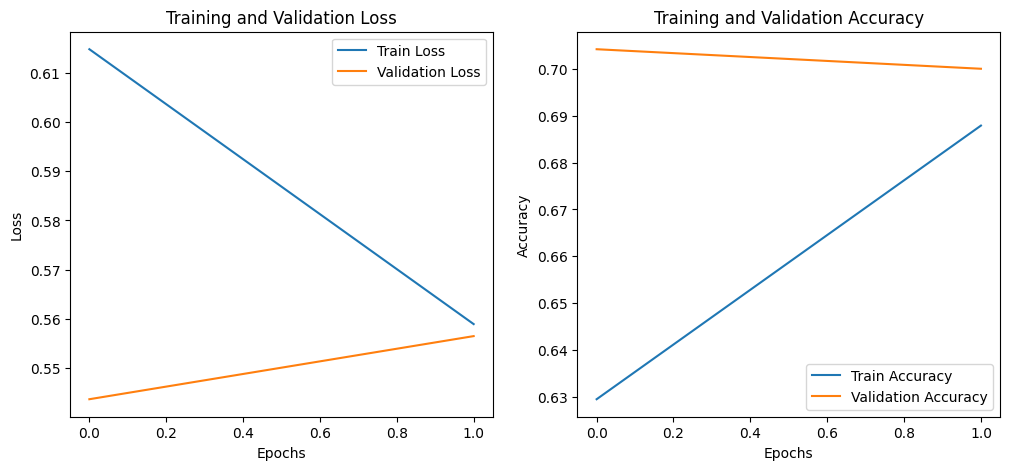

In [60]:
# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Pruebas del modelo: LSTM
</h1>

In [ ]:
VOCAB_SIZE = 1000

# Corregido: eliminamos .experimental.preprocessing
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',        # Para que devuelva índices de palabras
    output_sequence_length=200 # Equivale al max_len_ de tu pad_sequences
)

# Adaptamos al texto de entrenamiento (asegurándonos que sea un array de strings)
encoder.adapt(np.asarray(X_train))

model_LSTM = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [16]:
model_LSTM.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(2e-4),
              metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_LSTM.fit(X_train_final,Y_train_fixed, epochs=14,
                    validation_data=(X_test_final,Y_test_fixed), 
                    validation_steps=30)
end = time.perf_counter()

Epoch 1/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.6452 - f1_score: 0.5525 - loss: 0.5673 - val_accuracy: 0.6832 - val_f1_score: 0.6304 - val_loss: 0.5299
Epoch 2/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6941 - f1_score: 0.6426 - loss: 0.5171 - val_accuracy: 0.6995 - val_f1_score: 0.6716 - val_loss: 0.5210
Epoch 3/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7006 - f1_score: 0.6509 - loss: 0.5063 - val_accuracy: 0.6657 - val_f1_score: 0.5655 - val_loss: 0.5267
Epoch 4/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7048 - f1_score: 0.6560 - loss: 0.5001 - val_accuracy: 0.6911 - val_f1_score: 0.6408 - val_loss: 0.5198
Epoch 5/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7110 - f1_score: 0.6650 - loss: 0.4948 - val_accuracy: 0.6943 - val_f1_score: 0.6509 - val_loss: 0.5177
Epoch 6/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7159 - f1_score: 0.6723 - loss: 0.4905 - val_accuracy: 0.6888 - va

In [17]:
history_eval = model_LSTM.evaluate(X_test_final,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
lstm_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de LSTM es: {lstm_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6939 - f1_score: 0.6395 - loss: 0.5191
-------------------------------------
El entrenamiento de LSTM es: 145.92353376999995
Accuracy: 0.6939111351966858 | F1 Score: 0.6394806504249573


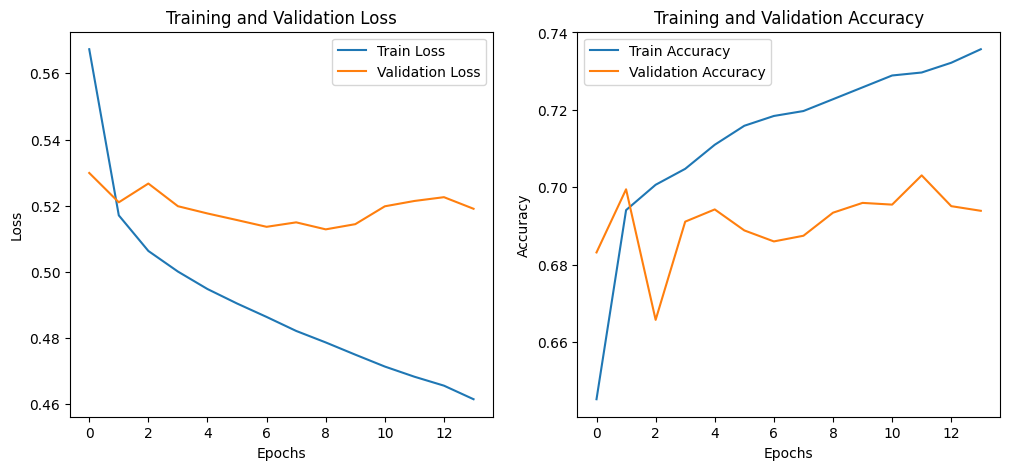

In [18]:
# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Pruebas del modelo: Bi-LSTM
</h1>

In [19]:
VOCAB_SIZE = 1000

# Corregido: eliminamos .experimental.preprocessing
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',        # Para que devuelva índices de palabras
    output_sequence_length=200 # Equivale al max_len_ de tu pad_sequences
)

# Adaptamos al texto de entrenamiento (asegurándonos que sea un array de strings)
encoder.adapt(np.asarray(X_train))

model_BiLSTM = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [20]:
model_BiLSTM.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(2e-4),
              metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_BiLSTM.fit(X_train_final,Y_train_fixed, epochs=14,
                    validation_data=(X_test_final,Y_test_fixed), 
                    validation_steps=30)
end = time.perf_counter()

Epoch 1/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6468 - f1_score: 0.5500 - loss: 0.5625 - val_accuracy: 0.6300 - val_f1_score: 0.4616 - val_loss: 0.5485
Epoch 2/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.6921 - f1_score: 0.6343 - loss: 0.5143 - val_accuracy: 0.6989 - val_f1_score: 0.6616 - val_loss: 0.5168
Epoch 3/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7035 - f1_score: 0.6512 - loss: 0.5009 - val_accuracy: 0.6789 - val_f1_score: 0.5937 - val_loss: 0.5141
Epoch 4/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7127 - f1_score: 0.6656 - loss: 0.4902 - val_accuracy: 0.7089 - val_f1_score: 0.6835 - val_loss: 0.5126
Epoch 5/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7214 - f1_score: 0.6796 - loss: 0.4821 - val_accuracy: 0.6774 - val_f1_score: 0.5927 - val_loss: 0.5148
Epoch 6/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7275 - f1_score: 0.6878 - loss: 0.4754 - val_accuracy: 0.7107 - va

In [21]:
history_eval = model_BiLSTM.evaluate(X_test_final,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
bilstm_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de LSTM es: {bilstm_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7001 - f1_score: 0.6598 - loss: 0.5328
-------------------------------------
El entrenamiento de LSTM es: 200.360266917
Accuracy: 0.7000889182090759 | F1 Score: 0.6598446369171143


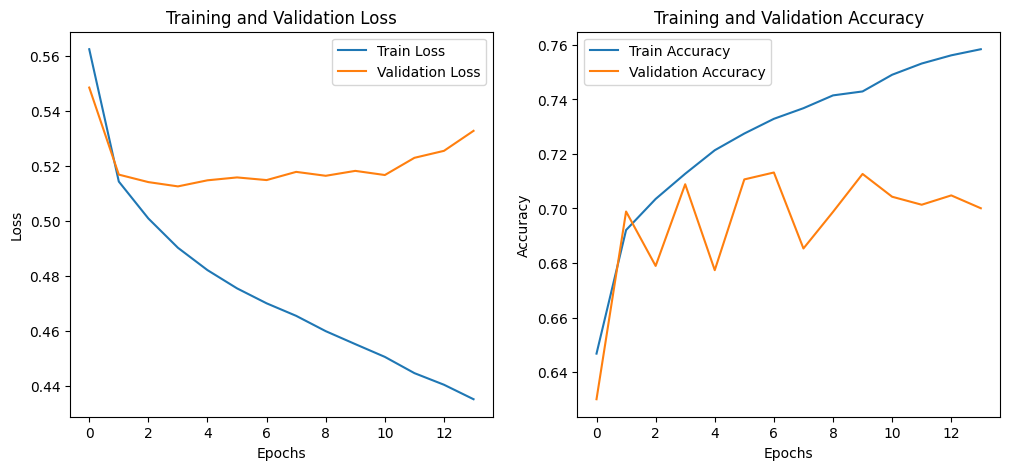

In [22]:
# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Pruebas del modelo: MLP
</h1>

In [11]:
HIDE = 64

tf.keras.backend.clear_session()

# Regularizacion
l2_val = 1e-4
l1_act = 1e-4
dropout_val = 0.4

model_MLP = tf.keras.Sequential([
    layers.Input(shape=(2500,)),
    
    # Capa 1
    layers.Dense(HIDE, kernel_regularizer=regularizers.l2(l2_val)),
    layers.BatchNormalization(), # <<-- Técnica nueva
    layers.Activation('relu'),
    layers.Dropout(dropout_val), # Subimos un pelín el dropout
    
    # Capa 2
    layers.Dense(HIDE // 2, activity_regularizer=regularizers.l1(l1_act)), 
    layers.BatchNormalization(), # <<-- Técnica nueva
    layers.Activation('relu'),
    layers.Dropout(dropout_val),
    
    layers.Dense(1) 
])

In [12]:
X_train_cv_mlp = X_train_cv.reshape(-1, 2500)
X_test_cv_mlp = X_test_cv.reshape(-1, 2500)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=2
)

model_MLP.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(0.000075),
              metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_MLP.fit(X_train_cv_mlp,Y_train_fixed, epochs=14,
                    validation_data=(X_test_cv_mlp,Y_test_fixed), batch_size=32,
                    validation_steps=30, callbacks=[lr_scheduler])
end = time.perf_counter()

Epoch 1/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5438 - f1_score: 0.3525 - loss: 0.7759 - val_accuracy: 0.5948 - val_f1_score: 0.4220 - val_loss: 0.6361 - learning_rate: 7.5000e-05
Epoch 2/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6057 - f1_score: 0.4891 - loss: 0.6795 - val_accuracy: 0.6479 - val_f1_score: 0.5481 - val_loss: 0.5935 - learning_rate: 7.5000e-05
Epoch 3/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6480 - f1_score: 0.5608 - loss: 0.6307 - val_accuracy: 0.6802 - val_f1_score: 0.6049 - val_loss: 0.5626 - learning_rate: 7.5000e-05
Epoch 4/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6759 - f1_score: 0.6069 - loss: 0.5983 - val_accuracy: 0.6938 - val_f1_score: 0.6240 - val_loss: 0.5423 - learning_rate: 7.5000e-05
Epoch 5/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6908 - f1_score: 0.6296 - loss: 0.5767 - val_accuracy: 0.7063 - val_f1_score: 0.6448 - val_loss: 0.5319 - learning_rate: 7.5000e-05


In [13]:
history_eval = model_MLP.evaluate(X_test_cv_mlp,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
mlp_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de MLP es: {mlp_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

704/704 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7096 - f1_score: 0.6557 - loss: 0.5260
-------------------------------------
El entrenamiento de MLP es: 50.92491806300001
Accuracy: 0.7095555663108826 | F1 Score: 0.6557446122169495


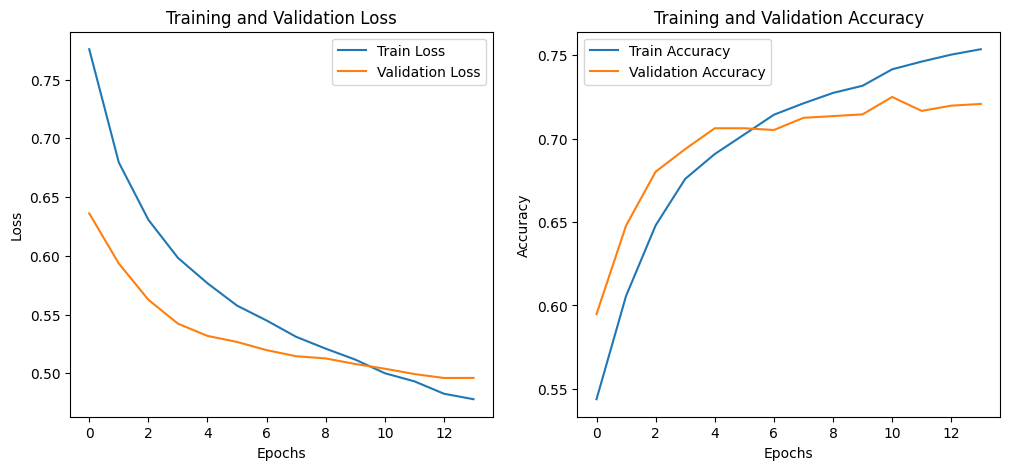

In [14]:
# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

Epoch 1/14
 114/2110 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4892 - f1_score: 0.3553 - loss: 0.9241

I0000 00:00:1777396081.226500    5933 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5503 - f1_score: 0.4203 - loss: 0.7754 - val_accuracy: 0.5875 - val_f1_score: 0.4159 - val_loss: 0.6459 - learning_rate: 7.5000e-05
Epoch 2/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6055 - f1_score: 0.4871 - loss: 0.6815 - val_accuracy: 0.6271 - val_f1_score: 0.5082 - val_loss: 0.6006 - learning_rate: 7.5000e-05
Epoch 3/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6445 - f1_score: 0.5522 - loss: 0.6313 - val_accuracy: 0.6729 - val_f1_score: 0.5890 - val_loss: 0.5681 - learning_rate: 7.5000e-05
Epoch 4/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6729 - f1_score: 0.5988 - loss: 0.5985 - val_accuracy: 0.6792 - val_f1_score: 0.5990 - val_loss: 0.5504 - learning_rate: 7.5000e-05
Epoch 5/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6897 - f1_score: 0.6259 - loss: 0.5745 - val_accuracy: 0.6865 - val_f1_score: 0.6106 - val_loss: 0.5406 - learning_rate: 7.5000e-05
Epoch 6/14

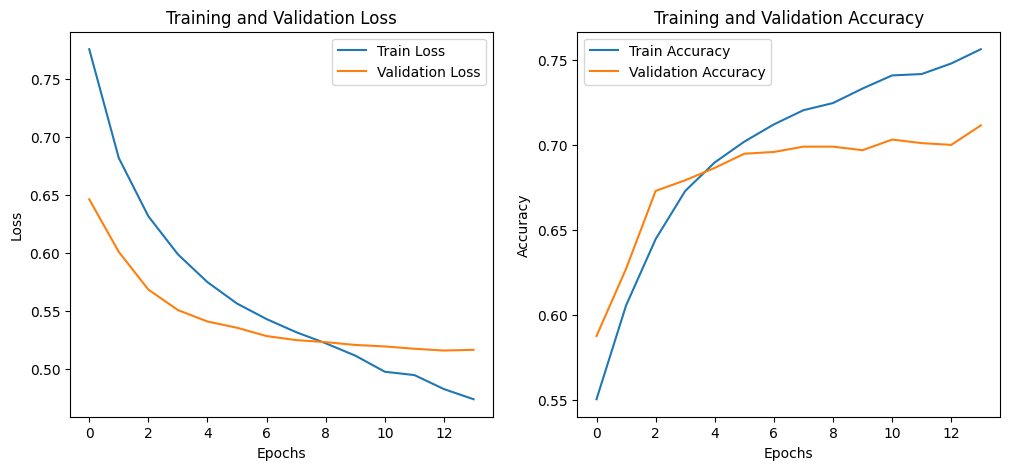

In [10]:
HIDE = 64

tf.keras.backend.clear_session()

# Regularizacion
l2_val = 1e-4
l1_act = 1e-4
dropout_val = 0.4

model_MLP = tf.keras.Sequential([
    layers.Input(shape=(2500,)),
    
    # Capa 1
    layers.Dense(HIDE, kernel_regularizer=regularizers.l2(l2_val)),
    layers.BatchNormalization(), # <<-- Técnica nueva
    layers.Activation('relu'),
    layers.Dropout(dropout_val), # Subimos un pelín el dropout
    
    # Capa 2
    layers.Dense(HIDE // 2, activity_regularizer=regularizers.l1(l1_act)), 
    layers.BatchNormalization(), # <<-- Técnica nueva
    layers.Activation('relu'),
    layers.Dropout(dropout_val),
    
    layers.Dense(1) 
])

X_train_tfidf_mlp = X_train_tfidf.reshape(-1, 2500)
X_test_tfidf_mlp = X_test_tfidf.reshape(-1, 2500)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=2
)

model_MLP.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(0.000075),
              metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_MLP.fit(X_train_tfidf_mlp,Y_train_fixed, epochs=14,
                    validation_data=(X_test_tfidf_mlp,Y_test_fixed), batch_size=32,
                    validation_steps=30, callbacks=[lr_scheduler])
end = time.perf_counter()

history_eval = model_MLP.evaluate(X_test_tfidf_mlp,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
mlp_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de MLP es: {mlp_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

Epoch 1/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.5357 - f1_score: 0.3570 - loss: 0.8613 - val_accuracy: 0.5781 - val_f1_score: 0.4444 - val_loss: 0.6951 - learning_rate: 7.5000e-05
Epoch 2/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5686 - f1_score: 0.4552 - loss: 0.7680 - val_accuracy: 0.5948 - val_f1_score: 0.4875 - val_loss: 0.6747 - learning_rate: 7.5000e-05
Epoch 3/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5792 - f1_score: 0.4650 - loss: 0.7365 - val_accuracy: 0.5844 - val_f1_score: 0.4404 - val_loss: 0.6619 - learning_rate: 7.5000e-05
Epoch 4/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5833 - f1_score: 0.4548 - loss: 0.7155 - val_accuracy: 0.5906 - val_f1_score: 0.4503 - val_loss: 0.6569 - learning_rate: 7.5000e-05
Epoch 5/14
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5900 - f1_score: 0.4561 - loss: 0.7012 - val_accuracy: 0.5885 - val_f1_score: 0.4397 - val_loss: 0.6498 - learning_rate: 7.5000e-05


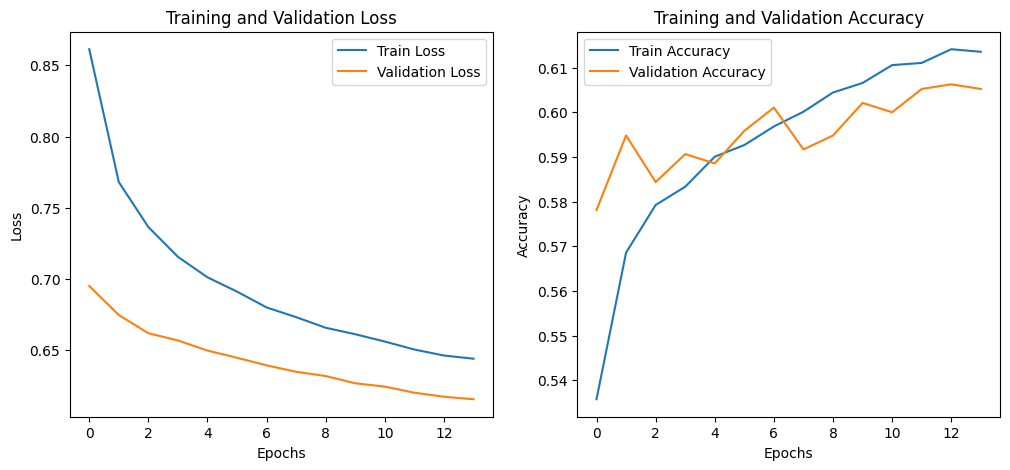

In [19]:
HIDE = 64

tf.keras.backend.clear_session()

# Regularizacion
l2_val = 1e-4
l1_act = 1e-4
dropout_val = 0.4

model_MLP = tf.keras.Sequential([
    layers.Input(shape=(100,)),
    
    # Capa 1
    layers.Dense(HIDE, kernel_regularizer=regularizers.l2(l2_val)),
    layers.BatchNormalization(), # <<-- Técnica nueva
    layers.Activation('relu'),
    layers.Dropout(dropout_val), # Subimos un pelín el dropout
    
    # Capa 2
    layers.Dense(HIDE // 2, activity_regularizer=regularizers.l1(l1_act)), 
    layers.BatchNormalization(), # <<-- Técnica nueva
    layers.Activation('relu'),
    layers.Dropout(dropout_val),
    
    layers.Dense(1) 
])

X_train_emb_mlp = X_train_emb.reshape(-1, 100)
X_test_emb_mlp = X_test_emb.reshape(-1, 100)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=2
)

model_MLP.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(0.000075),
              metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_MLP.fit(X_train_emb_mlp,Y_train_fixed, epochs=14,
                    validation_data=(X_test_emb_mlp,Y_test_fixed), batch_size=32,
                    validation_steps=30, callbacks=[lr_scheduler])
end = time.perf_counter()

history_eval = model_MLP.evaluate(X_test_emb_mlp,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
mlp_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de MLP es: {mlp_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Pruebas del modelo: GRU
</h1>

Epoch 1/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6088 - f1_score: 0.4841 - loss: 0.6198 - val_accuracy: 0.6823 - val_f1_score: 0.6554 - val_loss: 0.5596
Epoch 2/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6877 - f1_score: 0.6388 - loss: 0.5417 - val_accuracy: 0.7010 - val_f1_score: 0.6647 - val_loss: 0.5184
Epoch 3/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7154 - f1_score: 0.6787 - loss: 0.5065 - val_accuracy: 0.7437 - val_f1_score: 0.7602 - val_loss: 0.5049
Epoch 4/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7352 - f1_score: 0.7058 - loss: 0.4811 - val_accuracy: 0.7542 - val_f1_score: 0.7549 - val_loss: 0.4786
Epoch 5/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7514 - f1_score: 0.7275 - loss: 0.4570 - val_accuracy: 0.7620 - val_f1_score: 0.7547 - val_loss: 0.4563
Epoch 6/14
1055/1055 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7666 - f1_score: 0.7462 - loss: 0.4365 - val_accuracy: 0.7427 - val_f1_

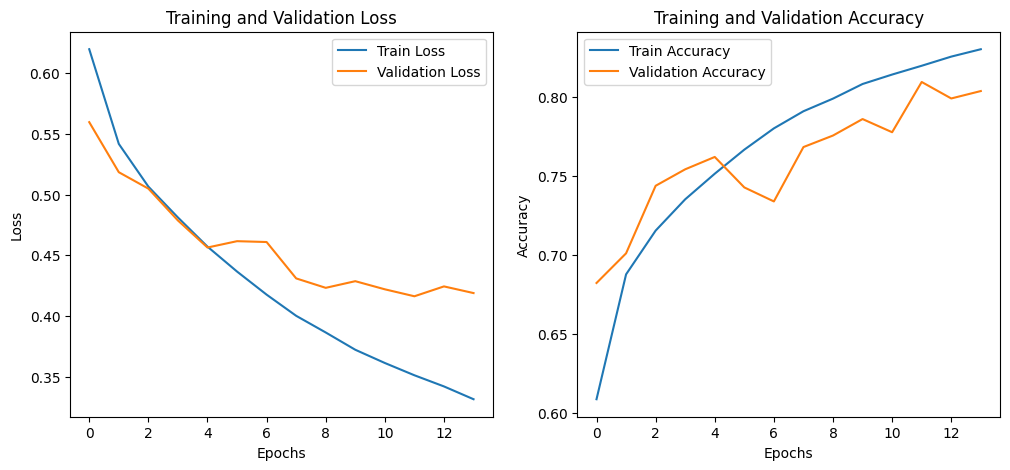

In [155]:
model_GRU = tf.keras.Sequential([
    layers.Input(shape=(max_len_,)),

    layers.Embedding(
        input_dim=25000,           # Debe ser igual al max_words que usaste arriba
        output_dim=200,           # Debe ser igual a las dimensiones de GloVe
        weights=[embedding_matrix], 
        trainable= True           # ¡No olvides esto para evitar el overfitting!
    ),
    
    layers.GRU(64, return_sequences=True), 

    layers.GRU(32, return_sequences=False), 
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.20),
    layers.Dense(1)
])

tf.keras.backend.clear_session()

model_GRU.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
            optimizer= tf.keras.optimizers.SGD(learning_rate=0.008, momentum=0.925, nesterov=True),
            metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_GRU.fit(train_sequences_matrix,Y_train_fixed, epochs=14, batch_size=64,
                    validation_data=(test_sequences_matrix,Y_test_fixed), 
                    validation_steps=30)
end = time.perf_counter()

history_eval = model_GRU.evaluate(test_sequences_matrix,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
gru_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de GRU es: {gru_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Pruebas del modelo: CNN
</h1>

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 55)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 55, 200)   │  5,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 54, 32)    │     12,832 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 53, 32)    │     19,232 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,032,129 (19.20 MB)

 Trainable params: 5,032,129 (19.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5557 - f1_score: 0.4574 - loss: 0.7599 - val_accuracy: 0.6143 - val_f1_score: 0.4724 - val_loss: 0.5972
Epoch 2/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6219 - f1_score: 0.5295 - loss: 0.6046 - val_accuracy: 0.6604 - val_f1_score: 0.5755 - val_loss: 0.5563
Epoch 3/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6690 - f1_score: 0.5956 - loss: 0.5471 - val_accuracy: 0.6896 - val_f1_score: 0.6328 - val_loss: 0.5246
Epoch 4/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7018 - f1_score: 0.6465 - loss: 0.5087 - val_accuracy: 0.7167 - val_f1_score: 0.6773 - val_loss: 0.4973
Epoch 5/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7293 - f1_score: 0.6868 - loss: 0.4756 - val_accuracy: 0.7310 - val_f1_score: 0.6980 - val_loss: 0.4750
Epoch 6/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7545 - f1_score: 0.7221 - loss: 0.4458 - val_accuracy: 0.7510 - val_f1_score: 0.7287

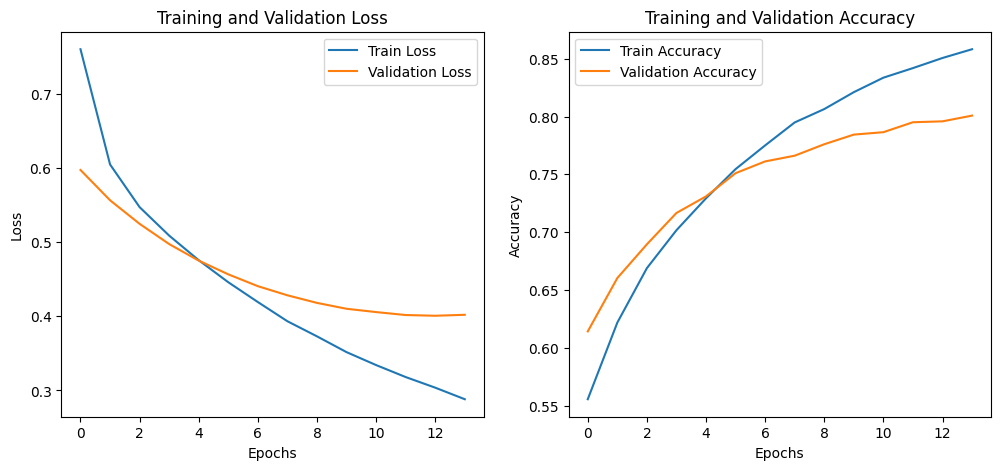

In [137]:
def CNN():
    inputs = tf.keras.layers.Input(shape=(max_len_,))

    layer = layers.Embedding(
        input_dim=25000,           # Debe ser igual al max_words que usaste arriba
        output_dim=200,           # Debe ser igual a las dimensiones de GloVe
        weights=[embedding_matrix], 
        trainable= True
    )(inputs)

    # Rama Bigramas (kernel_size=2)
    branch1 = tf.keras.layers.Conv1D(filters=32, kernel_size=2, activation='relu')(layer)
    branch1 = tf.keras.layers.GlobalMaxPooling1D()(branch1)
    
    # Rama Trigramas (kernel_size=3)
    branch2 = tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu')(layer)
    branch2 = tf.keras.layers.GlobalMaxPooling1D()(branch2)
    
    # 4. Concatenación y salida
    combined = tf.keras.layers.Concatenate()([branch1, branch2])
    combined = tf.keras.layers.Dropout(0.5)(combined)
    
    # Salida (Logits)
    outputs = tf.keras.layers.Dense(1)(combined)
    model = Model(inputs=inputs,outputs=outputs)
    return model

from tensorflow.keras.utils import plot_model

model_CNN = CNN()
model_CNN.summary()

tf.keras.backend.clear_session()

model_CNN.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(0.000135),
              metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_CNN.fit(train_sequences_matrix,Y_train_fixed, epochs=14, batch_size=128,
                    validation_data=(test_sequences_matrix,Y_test_fixed), 
                    validation_steps=30)
end = time.perf_counter()

history_eval = model_CNN.evaluate(test_sequences_matrix,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
cnn_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de CNN es: {cnn_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)

<h1 style="text-align: center; color: #ffffff; background-color: #2e86de; padding: 20px; border-radius: 10px;">
    Pruebas del modelo: Transformer
</h1>

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 55)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 55, 200)        │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 55, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 55, 200)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 55, 200)        │       258,032 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder_1           │ (None, 55, 200)        │       258,032 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 200)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,516,265 (21.04 MB)

 Trainable params: 5,516,265 (21.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.5991 - f1_score: 0.4704 - loss: 0.6321 - val_accuracy: 0.6776 - val_f1_score: 0.6200 - val_loss: 0.5422
Epoch 2/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6975 - f1_score: 0.6579 - loss: 0.5301 - val_accuracy: 0.7240 - val_f1_score: 0.6768 - val_loss: 0.4830
Epoch 3/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7421 - f1_score: 0.7180 - loss: 0.4677 - val_accuracy: 0.7776 - val_f1_score: 0.7843 - val_loss: 0.4596
Epoch 4/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7655 - f1_score: 0.7466 - loss: 0.4340 - val_accuracy: 0.7563 - val_f1_score: 0.7270 - val_loss: 0.4471
Epoch 5/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7783 - f1_score: 0.7608 - loss: 0.4116 - val_accuracy: 0.7896 - val_f1_score: 0.7950 - val_loss: 0.4468
Epoch 6/14
528/528 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7899 - f1_score: 0.7746 - loss: 0.3940 - val_accuracy: 0.7802 - val_f1_scor

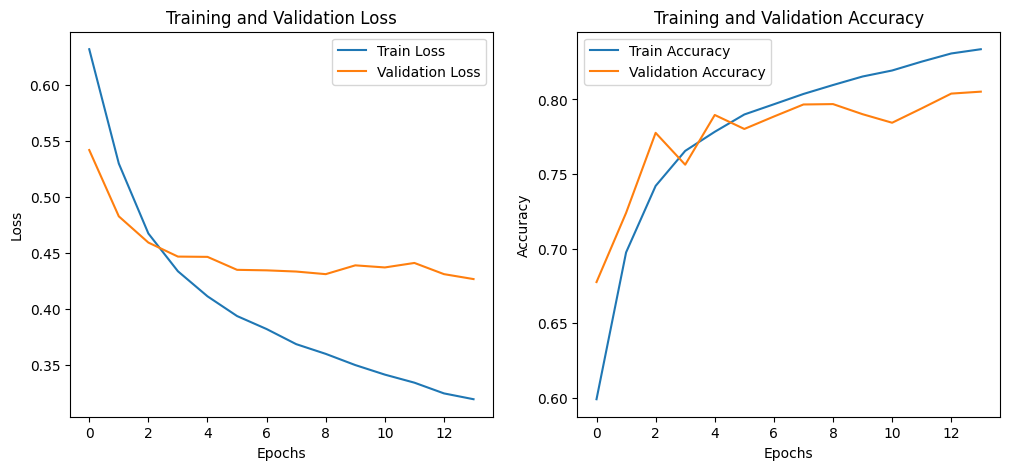

In [145]:
def Transformer():
    inputs = tf.keras.layers.Input(shape=(max_len_,))

    # 1. Embedding de Palabras con GloVe (Weights pre-entrenados)
    # IMPORTANTE: El tamaño debe coincidir con tu embedding_matrix (ej. 100)
    word_emb = tf.keras.layers.Embedding(
        input_dim=25000, 
        output_dim=200, 
        weights=[embedding_matrix], 
        trainable=True 
    )(inputs)

    # 2. Embedding Posicional (Sin GloVe, solo para posición)
    pos_indices = tf.range(start=0, limit=max_len_, delta=1)
    pos_emb = tf.keras.layers.Embedding(input_dim=max_len_, output_dim=200)(pos_indices)
    
    x = word_emb + pos_emb
    
    x = tf.keras.layers.SpatialDropout1D(0.3)(x)

    for _ in range(2): 
        # Quitamos kernel_regularizer de aquí para evitar el error de Keras Hub
        x = keras_hub.layers.TransformerEncoder(
            intermediate_dim=256, 
            num_heads=16,
            dropout=0.2, # Este dropout es potente para reducir overfitting
            activation="relu",
            layer_norm_epsilon=1e-05
        )(x)

    # 4. Global Average Pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    x = tf.keras.layers.Dropout(0.25)(x)
    
    # Aplicamos L2 y L1 aquí, donde la librería sí lo permite
    outputs = tf.keras.layers.Dense(
        1, 
        kernel_regularizer=tf.keras.regularizers.l2(1e-5), # Regulación de pesos
        activity_regularizer=tf.keras.regularizers.l1(1e-6) # Regulación de actividad
    )(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

from tensorflow.keras.utils import plot_model

model_Transformer = Transformer()
model_Transformer.summary()


tf.keras.backend.clear_session()

model_Transformer.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.000075),
              metrics=[metrics.BinaryAccuracy(name='accuracy'), metrics.F1Score(name='f1_score', threshold=0.5)])

start = time.perf_counter()
history_fit = model_Transformer.fit(train_sequences_matrix,Y_train_fixed, epochs=14, batch_size=128,
                    validation_data=(test_sequences_matrix,Y_test_fixed), 
                    validation_steps=30)
end = time.perf_counter()

history_eval = model_Transformer.evaluate(test_sequences_matrix,Y_test_fixed, return_dict=True) #devuelve las metricas en el mismo orden que se especifica al hacer el compile()
trans_time= end-start

print("-------------------------------------")
print(f"El entrenamiento de Transformer es: {trans_time}")
print(f"Accuracy: {history_eval['accuracy']} | F1 Score: {history_eval['f1_score']}")

# Usamos SOLO history_fit para la gráfica porque tiene los datos época a época
keras_dict = history_fit.history

# Esto de aquí es para adaptar los nombres a los que usa Keras por defecto (por si acaso)
history_for_plot = {
    "train_loss": keras_dict["loss"],        # Lista de pérdida de entrenamiento
    "val_loss":   keras_dict["val_loss"],    # Lista de pérdida de validación
    "train_acc":  keras_dict["accuracy"],    # Lista de acierto de entrenamiento
    "val_acc":    keras_dict["val_accuracy"] # Lista de acierto de validación
}

# Llamo a la misma función que en mis modelos para graficar el entrenamiento
plot_training_history(history_for_plot)